# 🎬 MovieMate — Conversational AI for Movie Discovery
**Course:** NLP  
**Dataset:** TMDB 5000 Movie Dataset (Kaggle)  
**Tech Stack:** Python · LangChain · Google Gemini · FAISS · Streamlit

---



## 1. Installation


In [1]:
import sys
!{sys.executable} -m pip install -q \
    pandas numpy \
    python-dotenv \
    sentence-transformers faiss-cpu \
    langchain langchain-google-genai \
    streamlit matplotlib seaborn

print("All packages installed successfully.")



All packages installed successfully.


## 2. API Key Setup




In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

key = os.getenv("GOOGLE_API_KEY")
print("GOOGLE_API_KEY:", "✅ Found" if key else "❌ Missing — check your .env file")


GOOGLE_API_KEY: ✅ Found


## 3. Dataset



### Why This Dataset?
The TMDB 5000 dataset contains rich metadata for ~4800 movies including:
- Title, genre, cast, director, runtime
- Plot summaries (ideal for semantic search)
- Ratings and vote counts
- Release dates and keywords

This makes it perfect for a conversational movie discovery system.


## 4. Data Loading & Exploration

In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")


movies  = pd.read_csv("data/tmdb_5000_movies.csv")
credits = pd.read_csv("data/tmdb_5000_credits.csv")

print("movies.csv shape: ", movies.shape)
print("credits.csv shape:", credits.shape)
print("\nmovies columns:\n", list(movies.columns))
print("\ncredits columns:\n", list(credits.columns))


movies.csv shape:  (4803, 20)
credits.csv shape: (4803, 4)

movies columns:
 ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

credits columns:
 ['movie_id', 'title', 'cast', 'crew']


In [ ]:

movies.head(3)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


In [ ]:

credits.head(3)


,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


In [ ]:

print("Missing values in movies.csv:")
print(movies.isnull().sum()[movies.isnull().sum() > 0])
print("\nMissing values in credits.csv:")
print(credits.isnull().sum()[credits.isnull().sum() > 0])


Missing values in movies.csv:
homepage        3091
overview           3
release_date       1
runtime            2
tagline          844
dtype: int64

Missing values in credits.csv:
Series([], dtype: int64)


In [ ]:

movies[["vote_average", "runtime", "popularity"]].describe().round(2)


,vote_average,runtime,popularity
count,4803.00,4801.00,4803.00
mean,6.09,106.88,21.49
std,1.19,22.61,31.82
min,0.00,0.00,0.00
25%,5.60,94.00,4.67
50%,6.20,103.00,12.92
75%,6.80,118.00,28.31
max,10.00,338.00,875.58


## 5. Data Preprocessing

The raw dataset has several JSON-like string columns (genres, cast, crew, keywords)
that need parsing. We also merge both CSVs and extract clean text fields.


In [7]:
from data_loader import load_and_clean

df = load_and_clean()


Loading CSV files...
  Movies:  4803 rows
  Credits: 4803 rows
  After merge: 4809 rows
Parsing genres, cast, crew...

Clean dataset saved → data/movies_clean.csv
Total movies:  4796
Columns:       ['title', 'summary', 'genre', 'year', 'rating', 'vote_count', 'runtime', 'director', 'cast', 'keywords', 'popularity', 'original_language']

Missing values:
title                0
summary              0
genre                0
year                 1
rating               0
vote_count           0
runtime              0
director             0
cast                 0
keywords             0
popularity           0
original_language    0
dtype: int64

Sample:
                                      title  year  rating                               genre
0                                    Avatar  2009     7.2          Action, Adventure, Fantasy
1  Pirates of the Caribbean: At World's End  2007     6.9          Adventure, Fantasy, Action
2                                   Spectre  2015     6.3        

In [ ]:

print("Clean dataset shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nSample rows:")
df[["title", "year", "rating", "genre", "director"]].head(10)


Clean dataset shape: (4796, 12)

Columns: ['title', 'summary', 'genre', 'year', 'rating', 'vote_count', 'runtime', 'director', 'cast', 'keywords', 'popularity', 'original_language']

Sample rows:


,title,year,rating,genre,director
0,Avatar,2009,7.2,"Action, Adventure, Fantasy",James Cameron
1,Pirates of the Caribbean: At World's End,2007,6.9,"Adventure, Fantasy, Action",Gore Verbinski
2,Spectre,2015,6.3,"Action, Adventure, Crime",Sam Mendes
3,The Dark Knight Rises,2012,7.6,"Action, Crime, Drama",Christopher Nolan
4,John Carter,2012,6.1,"Action, Adventure, Science Fiction",Andrew Stanton
5,Spider-Man 3,2007,5.9,"Fantasy, Action, Adventure",Sam Raimi
6,Tangled,2010,7.4,"Animation, Family",Byron Howard
7,Avengers: Age of Ultron,2015,7.3,"Action, Adventure, Science Fiction",Joss Whedon
8,Harry Potter and the Half-Blood Prince,2009,7.4,"Adventure, Fantasy, Family",David Yates
9,Batman v Superman: Dawn of Justice,2016,5.7,"Action, Adventure, Fantasy",Zack Snyder


In [ ]:

print("Missing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
title                0
summary              0
genre                0
year                 1
rating               0
vote_count           0
runtime              0
director             0
cast                 0
keywords             0
popularity           0
original_language    0
dtype: int64


In [ ]:

print("Data types:")
print(df.dtypes)


Data types:
title                 object
summary               object
genre                 object
year                   Int64
rating               float64
vote_count             int64
runtime              float64
director              object
cast                  object
keywords              object
popularity           float64
original_language     object
dtype: object


## 6. Exploratory Data Analysis (EDA)

Understanding the characteristics of the dataset before building the model.


In [11]:
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

os.makedirs("outputs", exist_ok=True)
sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv("data/movies_clean.csv")
df["year"]    = pd.to_numeric(df["year"],    errors="coerce")
df["rating"]  = pd.to_numeric(df["rating"],  errors="coerce")
df["runtime"] = pd.to_numeric(df["runtime"], errors="coerce")


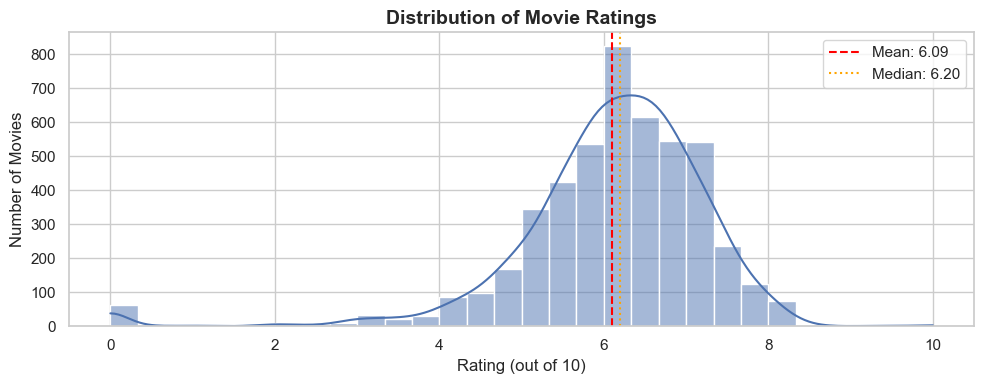

Mean: 6.09 | Median: 6.20 | Std: 1.19


In [ ]:
#Plot 1: Rating Distribution 
ratings = df["rating"].dropna()
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(ratings, bins=30, kde=True, color="#4C72B0", ax=ax)
ax.axvline(ratings.mean(),   color="red",    ls="--", lw=1.5, label=f"Mean: {ratings.mean():.2f}")
ax.axvline(ratings.median(), color="orange", ls=":",  lw=1.5, label=f"Median: {ratings.median():.2f}")
ax.set_title("Distribution of Movie Ratings", fontsize=14, fontweight="bold")
ax.set_xlabel("Rating (out of 10)"); ax.set_ylabel("Number of Movies"); ax.legend()
plt.tight_layout(); plt.savefig("outputs/1_rating_distribution.png", dpi=150); plt.show()
print(f"Mean: {ratings.mean():.2f} | Median: {ratings.median():.2f} | Std: {ratings.std():.2f}")


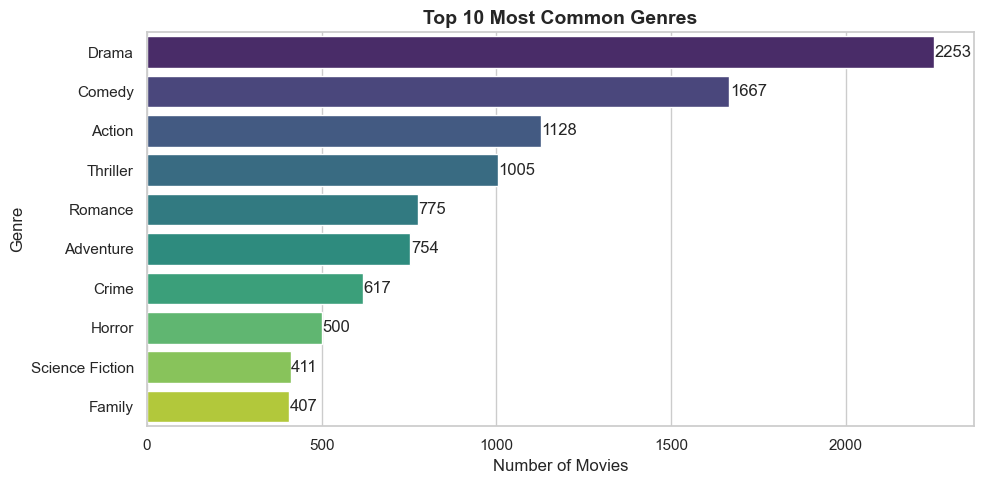

In [ ]:
#Plot 2: Top 10 Genres 
all_genres = []
for val in df["genre"].dropna():
    all_genres.extend([g.strip() for g in str(val).split(",")])
counts = Counter(all_genres); counts.pop("Unknown", None)
top10  = pd.DataFrame(counts.most_common(10), columns=["Genre", "Count"])

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top10, x="Count", y="Genre", palette="viridis", ax=ax)
ax.set_title("Top 10 Most Common Genres", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Movies")
for bar in ax.patches:
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2, f"{int(bar.get_width())}", va="center")
plt.tight_layout(); plt.savefig("outputs/2_top_genres.png", dpi=150); plt.show()


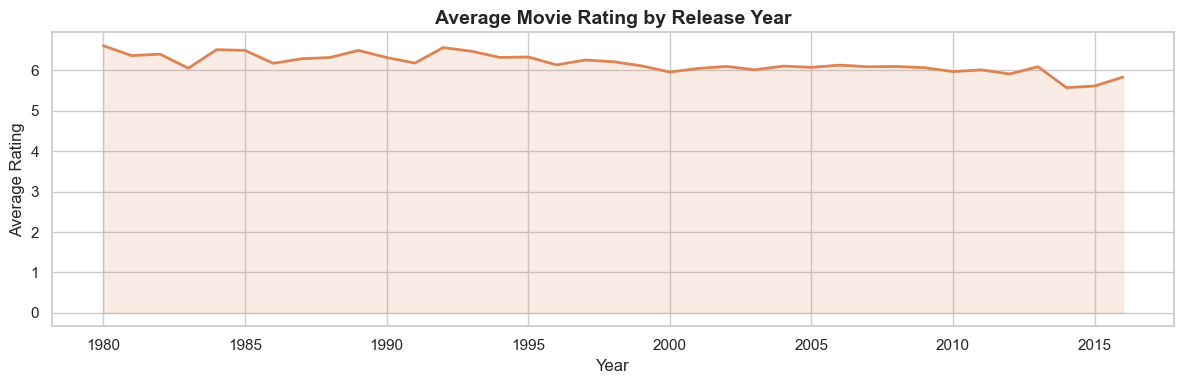

In [ ]:
#Plot 3: Average Rating by Year 
yearly = (df.dropna(subset=["year","rating"])
            .groupby("year")["rating"]
            .agg(["mean","count"]).reset_index())
yearly = yearly[(yearly["count"]>=3) & (yearly["year"]>=1980) & (yearly["year"]<=2024)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(yearly["year"], yearly["mean"], color="#DD8452", lw=2)
ax.fill_between(yearly["year"], yearly["mean"], alpha=0.15, color="#DD8452")
ax.set_title("Average Movie Rating by Release Year", fontsize=14, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Average Rating")
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
plt.tight_layout(); plt.savefig("outputs/3_rating_by_year.png", dpi=150); plt.show()


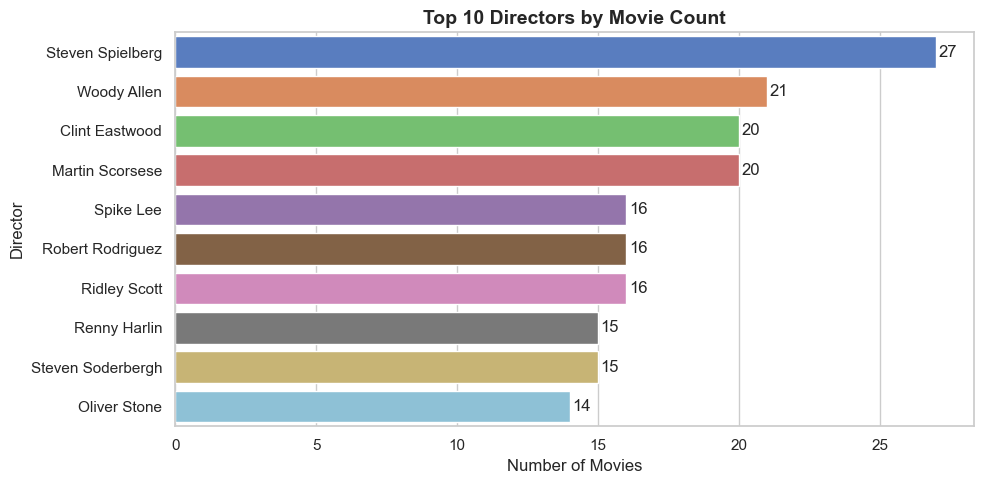

In [ ]:
#Plot 4: Top 10 Directors 
dirs = (df["director"].dropna()
         .loc[df["director"] != "Unknown"]
         .value_counts().head(10).reset_index())
dirs.columns = ["Director", "Count"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=dirs, x="Count", y="Director", palette="muted", ax=ax)
ax.set_title("Top 10 Directors by Movie Count", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Movies")
for bar in ax.patches:
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2, f"{int(bar.get_width())}", va="center")
plt.tight_layout(); plt.savefig("outputs/4_top_directors.png", dpi=150); plt.show()


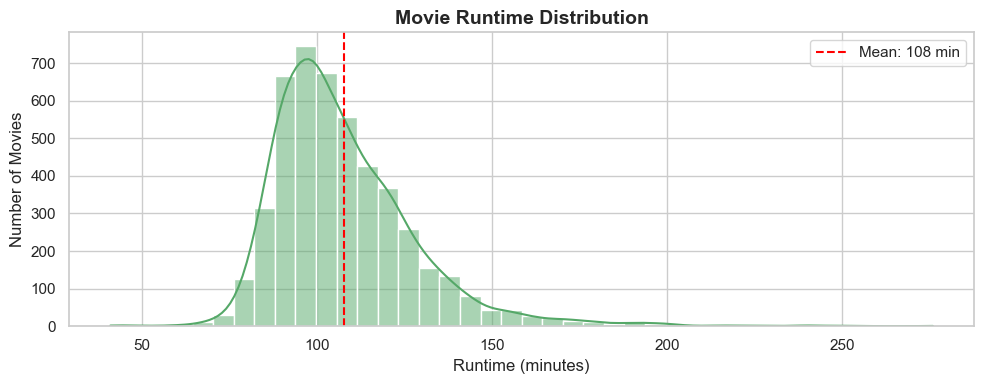

Mean runtime: 108 min | Median: 104 min


In [ ]:
#Plot 5: Runtime Distribution
rt = df["runtime"].dropna(); rt = rt[(rt > 30) & (rt < 300)]

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(rt, bins=40, kde=True, color="#55A868", ax=ax)
ax.axvline(rt.mean(), color="red", ls="--", lw=1.5, label=f"Mean: {rt.mean():.0f} min")
ax.set_title("Movie Runtime Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Runtime (minutes)"); ax.set_ylabel("Number of Movies"); ax.legend()
plt.tight_layout(); plt.savefig("outputs/5_runtime_distribution.png", dpi=150); plt.show()
print(f"Mean runtime: {rt.mean():.0f} min | Median: {rt.median():.0f} min")


## 7. Feature Representation & Similarity Search




In [17]:
from vectorstore import load_vectorstore, retrieve

index, df_vs, texts = load_vectorstore()

⚡ Loading vectorstore (instant)...


### 7(a) Test Retrieval

In [18]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("all-MiniLM-L6-v2")

test_queries = [
    "action movies after 2010",
    "feel-good comedy movies",
    "Christopher Nolan films",
    "romantic movies with high ratings",
    "animated family movies",
]

for query in test_queries:
    results = retrieve(query, embed_model, index, df_vs, top_k=3)

    print(f"\nQuery: '{query}'")
    print(results[["title", "genre", "year", "rating"]])
    print("-" * 60)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Query: 'action movies after 2010'
                 title                       genre    year  rating
403   Last Action Hero  Adventure, Fantasy, Action  1993.0     6.1
711                RED   Action, Adventure, Comedy  2010.0     6.6
3373           Redbelt                       Drama  2008.0     6.4
------------------------------------------------------------

Query: 'feel-good comedy movies'
                             title                genre    year  rating
3274    It's Kind of a Funny Story        Comedy, Drama  2010.0     6.9
4176  The Greatest Movie Ever Sold  Comedy, Documentary  2011.0     6.4
4306                 Extreme Movie               Comedy  2008.0     3.9
------------------------------------------------------------

Query: 'Christopher Nolan films'
             title                              genre    year  rating
95    Interstellar  Adventure, Drama, Science Fiction  2014.0     8.1
1196  The Prestige           Drama, Mystery, Thriller  2006.0     8.0
96       

In [ ]:

print("Sample embedding input text for first movie:")
print("─" * 60)
print(texts[0])


Sample embedding input text for first movie:
────────────────────────────────────────────────────────────
Title: Avatar. Genre: Action, Adventure, Fantasy. Director: James Cameron. Cast: Sam Worthington, Zoe Saldana, Sigourney Weaver. Year: 2009.0. Rating: 7.2 out of 10. Runtime: 162.0 minutes. Keywords: culture clash, future, space war, space colony, society. Summary: In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization..


## 8. Conversational Movie Chatbot (RAG)

### How it Works
```
User Query
    ↓
Embed query (sentence-transformers)
    ↓
FAISS similarity search → top 5 movies
    ↓
Build augmented prompt: query + retrieved movies
    ↓
Google Gemini generates natural language response
    ↓
Store turn in conversation history (enables multi-turn)
```
This is called **Retrieval-Augmented Generation (RAG)** — the LLM only 
recommends movies that actually exist in our dataset.


In [20]:
import langchain
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
print(f"LangChain version: {langchain.__version__}")

LangChain version: 1.2.14


In [21]:
from chatbot import MovieChatbot
bot = MovieChatbot()


Loading vector store...
⚡ Loading vectorstore (instant)...
Loading embedding model: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Connecting to Gemini (gemini-2.5-flash)...
MovieMate ready!



In [ ]:
#  Simple recommendation 
query = "Suggest some good sci-fi movies"
reply = bot.chat(query)
print(f"User: {query}")
print(f"\nMovieMate:\n{reply}")


User: Suggest some good sci-fi movies

MovieMate:
Certainly! Here are some sci-fi movies that might be just what you're looking for:

*   For an action-packed space adventure, **Star Trek Into Darkness (2013)** is a great choice, rated 7.4/10, offering a thrilling ride with familiar characters.
*   If you're interested in a more serious and mysterious sci-fi, **Prometheus (2012)**, rated 6.3/10, explores the dark origins of mankind in the universe.
*   Looking for a laugh? **Galaxy Quest (1999)** is a fantastic sci-fi comedy rated 6.9/10 that cleverly parodies space opera shows.
*   Another comedic option is **Mars Attacks! (1996)**, a quirky sci-fi comedy rated 6.1/10, known for its unique take on an alien invasion.
*   Lastly, for a psychological sci-fi mystery, **Sphere (1998)**, rated 5.8/10, delves into the discovery of an ancient spacecraft deep underwater.


In [ ]:
#  Follow-up query 
query = "Only those released after 2010"
reply = bot.chat(query)
print(f"User: {query}")
print(f"\nMovieMate:\n{reply}")


User: Only those released after 2010

MovieMate:
It looks like none of the movies I have in my current list were released strictly *after 2010*.

Perhaps you could rephrase your query, or try a different year range?


In [ ]:
# Director query 
bot.reset()
query = "What movies did Christopher Nolan direct?"
reply = bot.chat(query)
print(f"User: {query}")
print(f"\nMovieMate:\n{reply}")


Conversation cleared.
User: What movies did Christopher Nolan direct?

MovieMate:
Certainly! Christopher Nolan has directed some fantastic and highly-rated films. Here are a few I found for you:

*   **Interstellar (2014)**: This Adventure, Drama, Science Fiction epic, rated 8.1/10, takes you on a breathtaking journey through space and time.
*   **Inception (2010)**: A mind-bending Action, Thriller, Science Fiction film, also rated 8.1/10, that delves into the world of dreams and corporate espionage.
*   **The Prestige (2006)**: This captivating Drama, Mystery, Thriller, with a rating of 8.0/10, tells a dark and intricate story of rival magicians.


In [ ]:
# Complex natural language query 
bot.reset()
query = "I want a feel-good movie under 2 hours with a rating above 7"
reply = bot.chat(query)
print(f"User: {query}")
print(f"\nMovieMate:\n{reply}")


Conversation cleared.
User: I want a feel-good movie under 2 hours with a rating above 7

MovieMate:
I'm sorry, MovieMate couldn't find any feel-good movies from the retrieved list that are under 2 hours with a rating above 7.0.

Would you like to adjust your preferences or try a different kind of movie?


In [ ]:
#  Multi-turn conversation 
bot.reset()
turns = [
    "Recommend some thriller movies",
    "Which of those has the highest rating?",
    "Tell me more about that one",
]
for q in turns:
    print(f"User: {q}")
    r = bot.chat(q)
    print(f"MovieMate: {r}")
    print("─" * 60)


Conversation cleared.
User: Recommend some thriller movies
MovieMate: Certainly! Based on your interest in thriller movies, here are a few options from our database that blend suspense and tension:

*   **Sinister (2012)**: This Horror, Thriller, Mystery film, rated 6.7/10, follows a true-crime novelist who uncovers a terrifying mystery in his new home.
*   **1408 (2007)**: A gripping Horror, Thriller with a rating of 6.5/10, it features a paranormal debunker who confronts genuine terror in a fabled hotel room.
*   **As Above, So Below (2014)**: This Horror, Thriller, rated 6.1/10, takes you on a suspenseful journey as explorers uncover dark secrets beneath the streets of Paris.
*   **Twixt (2011)**: For a more atmospheric Horror, Thriller, rated 5.0/10, you might enjoy this tale of a writer caught up in a small-town murder mystery.
────────────────────────────────────────────────────────────
User: Which of those has the highest rating?
MovieMate: Based on the movies I have available, 

## 9. Interactive Web Interface

The Streamlit app provides a full chat interface with:
- Conversation history
- Example prompt buttons in the sidebar  
- Clear conversation button




## 10. Evaluation & Reflection

In [ ]:

from vectorstore import load_vectorstore, retrieve
from sentence_transformers import SentenceTransformer

index, df_vs, _ = load_vectorstore()
model = SentenceTransformer("all-MiniLM-L6-v2")

eval_set = [
    ("action movies",   ["Action"]),
    ("comedy films",    ["Comedy"]),
    ("horror movies",   ["Horror"]),
    ("animated movies", ["Animation"]),
    ("romance films",   ["Romance"]),
]

print(f"{'Query':<25} {'Relevant/5':>10}  Top Result")
print("─" * 65)
for query, expected in eval_set:
    results = retrieve(query, model, index, df_vs, top_k=5)
    hits = sum(
        any(e.lower() in str(row["genre"]).lower() for e in expected)
        for _, row in results.iterrows()
    )
    top = results.iloc[0]["title"]
    print(f"{query:<25} {hits}/5          {top}")


⚡ Loading vectorstore (instant)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Query                     Relevant/5  Top Result
─────────────────────────────────────────────────────────────────
action movies             4/5          Last Action Hero
comedy films              5/5          The Greatest Movie Ever Sold
horror movies             4/5          The Horror Network Vol. 1
animated movies           3/5          Shrek
romance films             4/5          Conversations with Other Women
